In [ ]:
!pip install lightgbm shap pandas numpy matplotlib scikit-learn

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# 18 months of daily sales for 10 SKUs
dates = pd.date_range(start='2024-01-01', periods=540, freq='D')
skus = ['Tomato', 'Banana', 'Milk_500ml', 'Curd_200g', 'Spinach',
        'Apple', 'Bread', 'Eggs_12pk', 'Orange', 'Potato']

rows = []
for sku in skus:
    base_demand = np.random.randint(50, 200)
    for date in dates:
        # Seasonality
        day_of_week = date.dayofweek
        weekend_boost = 1.3 if day_of_week >= 5 else 1.0
        # Monthly seasonality
        month_factor = 1 + 0.1 * np.sin(2 * np.pi * date.month / 12)
        # Promotional spike (random 5% of days)
        promo = np.random.choice([0, 1], p=[0.95, 0.05])
        promo_boost = 1.5 if promo else 1.0
        # Weather proxy (temperature index)
        weather = 25 + 10 * np.sin(2 * np.pi * date.dayofyear / 365) + np.random.normal(0, 2)
        # Final demand with noise
        demand = int(base_demand * weekend_boost * month_factor * promo_boost
                     * (1 + 0.01 * (weather - 25)) + np.random.normal(0, 10))
        demand = max(0, demand)
        rows.append({
            'date': date,
            'sku': sku,
            'demand': demand,
            'day_of_week': day_of_week,
            'month': date.month,
            'day_of_year': date.dayofyear,
            'is_weekend': int(day_of_week >= 5),
            'is_promo': promo,
            'weather_index': round(weather, 2)
        })

df = pd.DataFrame(rows)
print(df.shape)
df.head(10)

(5400, 9)


,date,sku,demand,day_of_week,month,day_of_year,is_weekend,is_promo,weather_index
0,2024-01-01,Tomato,155,0,1,1,0,0,26.26
1,2024-01-02,Tomato,155,1,1,2,0,0,23.51
2,2024-01-03,Tomato,153,2,1,3,0,0,23.75
3,2024-01-04,Tomato,159,3,1,4,0,0,25.85
4,2024-01-05,Tomato,181,4,1,5,0,0,28.78
5,2024-01-06,Tomato,205,5,1,6,1,0,26.08
6,2024-01-07,Tomato,207,6,1,7,1,0,25.70
7,2024-01-08,Tomato,161,0,1,8,0,0,26.66
8,2024-01-09,Tomato,171,1,1,9,0,0,27.38
9,2024-01-10,Tomato,167,2,1,10,0,0,22.66


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

# Feature engineering
df = df.sort_values(['sku', 'date']).reset_index(drop=True)

# Lag features
for lag in [1, 3, 7, 14]:
    df[f'lag_{lag}'] = df.groupby('sku')['demand'].shift(lag)

# Rolling mean features
for window in [7, 14, 30]:
    df[f'rolling_mean_{window}'] = df.groupby('sku')['demand'].transform(
        lambda x: x.shift(1).rolling(window).mean()
    )

# SKU encoding
df['sku_code'] = df['sku'].astype('category').cat.codes

# Drop nulls from lag creation
df = df.dropna().reset_index(drop=True)

# Features and target
features = ['sku_code', 'day_of_week', 'month', 'day_of_year',
            'is_weekend', 'is_promo', 'weather_index',
            'lag_1', 'lag_3', 'lag_7', 'lag_14',
            'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']

X = df[features]
y = df['demand']

# Train/test split (last 60 days as test)
split_date = df['date'].max() - pd.Timedelta(days=60)
train_mask = df['date'] <= split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train LightGBM
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(50, verbose=False)])

# Evaluate
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Naive baseline (predict previous day's demand)
naive_pred = df[~train_mask]['lag_1']
naive_mape = mean_absolute_percentage_error(y_test, naive_pred) * 100

print(f"LightGBM MAPE: {mape:.2f}%")
print(f"Naive Baseline MAPE: {naive_mape:.2f}%")

LightGBM MAPE: 6.20%
Naive Baseline MAPE: 15.98%


/tmp/ipykernel_1063/1146484847.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


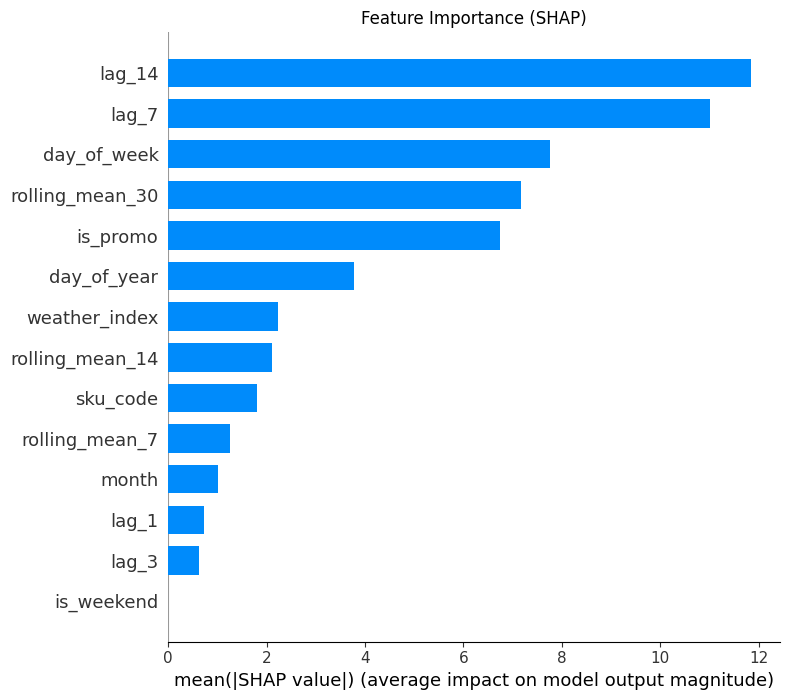

SHAP plot saved

Avg daily waste cost (naive):  ₹914.47
Avg daily waste cost (model):  ₹335.35
Cost reduction:                63.3%

── Reorder Trigger Report ──
       sku  predicted_demand  safety_stock_threshold  reorder_flag
     Apple             134.0                   161.0          True
    Banana             135.0                   162.0          True
     Bread             143.0                   171.0          True
 Curd_200g             113.0                   135.0          True
 Eggs_12pk             101.0                   121.0          True
Milk_500ml             169.0                   203.0          True
    Orange             253.0                   303.0          True
    Potato             135.0                   162.0          True
   Spinach             141.0                   170.0          True
    Tomato             159.0                   191.0          True


In [ ]:
import shap
import matplotlib.pyplot as plt

# ── SHAP explanation ──────────────────────────────────────────────
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150)
plt.show()
print("SHAP plot saved")

# ── Spoilage cost model ───────────────────────────────────────────
STOCKOUT_PENALTY = 50   # cost per unit of unmet demand
SPOILAGE_COST    = 20   # cost per unit of excess inventory

def total_waste_cost(actual, predicted):
    error = predicted - actual
    cost = np.where(error < 0,
                    -error * STOCKOUT_PENALTY,   # under-predicted → stockout
                     error * SPOILAGE_COST)      # over-predicted  → spoilage
    return cost

baseline_cost = total_waste_cost(y_test.values, naive_pred.values).mean()
model_cost    = total_waste_cost(y_test.values, y_pred).mean()
improvement   = (baseline_cost - model_cost) / baseline_cost * 100

print(f"\nAvg daily waste cost (naive):  ₹{baseline_cost:.2f}")
print(f"Avg daily waste cost (model):  ₹{model_cost:.2f}")
print(f"Cost reduction:                {improvement:.1f}%")

# ── Reorder trigger system ────────────────────────────────────────
SAFETY_STOCK_MULTIPLIER = 1.2  # 20% buffer above predicted demand

latest = df[df['date'] == df['date'].max()].copy()
latest_X = latest[features]
latest_pred = model.predict(latest_X)

reorder_df = pd.DataFrame({
    'sku': latest['sku'].values,
    'predicted_demand': latest_pred.round(0),
    'safety_stock_threshold': (latest_pred * SAFETY_STOCK_MULTIPLIER).round(0),
    'reorder_flag': latest_pred * SAFETY_STOCK_MULTIPLIER > latest_pred
})

print("\n── Reorder Trigger Report ──")
print(reorder_df.to_string(index=False))

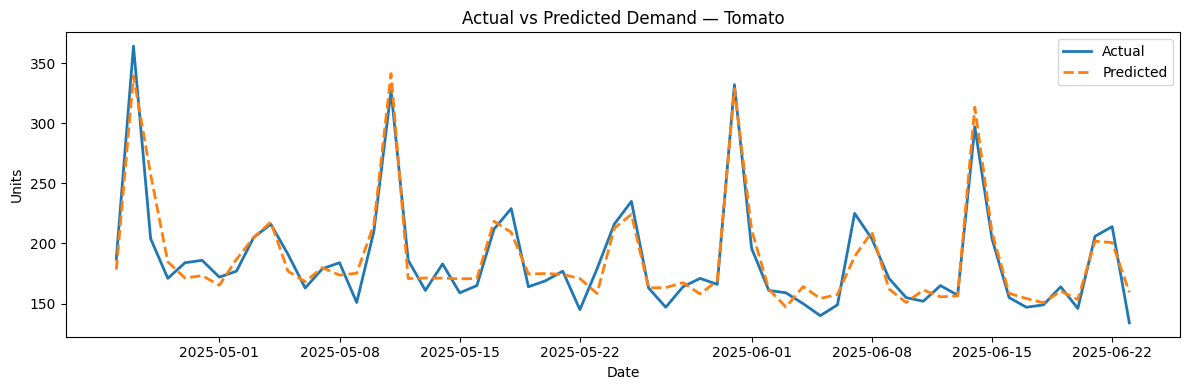

Demand plot saved


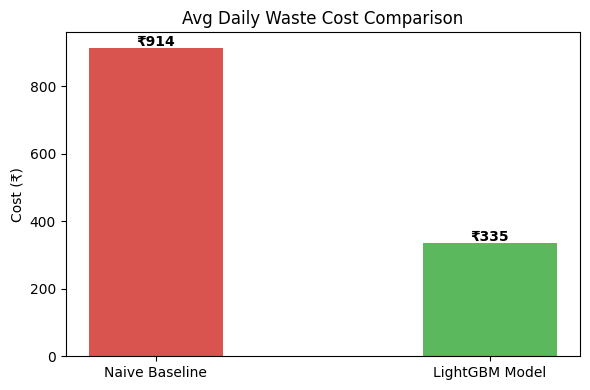

Cost comparison plot saved

── Summary ──
LightGBM MAPE:        6.20%
Naive MAPE:           15.98%
Cost Reduction:       63.3%
Files saved:          sales_data.csv, reorder_report.csv, predictions.csv
Plots saved:          shap_importance.png, actual_vs_predicted.png, waste_cost_comparison.png


In [ ]:
# ── Actual vs Predicted plot ──────────────────────────────────────
test_df = df[~train_mask].copy()
test_df['predicted'] = y_pred

sample_sku = 'Tomato'
sku_df = test_df[test_df['sku'] == sample_sku]

plt.figure(figsize=(12, 4))
plt.plot(sku_df['date'], sku_df['demand'], label='Actual', linewidth=2)
plt.plot(sku_df['date'], sku_df['predicted'], label='Predicted',
         linewidth=2, linestyle='--')
plt.title(f'Actual vs Predicted Demand — {sample_sku}')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print("Demand plot saved")

# ── Waste cost comparison bar chart ──────────────────────────────
plt.figure(figsize=(6, 4))
plt.bar(['Naive Baseline', 'LightGBM Model'],
        [baseline_cost, model_cost],
        color=['#d9534f', '#5cb85c'], width=0.4)
plt.title('Avg Daily Waste Cost Comparison')
plt.ylabel('Cost (₹)')
for i, v in enumerate([baseline_cost, model_cost]):
    plt.text(i, v + 5, f'₹{v:.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('waste_cost_comparison.png', dpi=150)
plt.show()
print("Cost comparison plot saved")

# ── Save outputs ──────────────────────────────────────────────────
df.to_csv('sales_data.csv', index=False)
reorder_df.to_csv('reorder_report.csv', index=False)
test_df[['date','sku','demand','predicted']].to_csv('predictions.csv', index=False)

print("\n── Summary ──")
print(f"LightGBM MAPE:        {mape:.2f}%")
print(f"Naive MAPE:           {naive_mape:.2f}%")
print(f"Cost Reduction:       {improvement:.1f}%")
print(f"Files saved:          sales_data.csv, reorder_report.csv, predictions.csv")
print(f"Plots saved:          shap_importance.png, actual_vs_predicted.png, waste_cost_comparison.png")